In [1]:
# Load libraries
import numpy as np
import pandas as pd
import torch
import timesfm
import matplotlib.pyplot as plt
import time
import json

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

from data_util import *

c:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\timesfm_LOCAL_ARCHIVE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Last data preparation update

In [2]:
def get_timesfm_metrics(model_tsfm, test_dataset, scaler):
    """
    Calcula RMSE, MSE y MAE for TimesFM 2.5 model over the test dataset.
    """
    all_preds = []
    all_targets = []


    inputs_list = [test_dataset[i][0].numpy() for i in range(len(test_dataset))]
    targets_list = [test_dataset[i][3].numpy() for i in range(len(test_dataset))]
    
    start_time = time.time()
    # freq_type se obtiene directamente del objeto dataset que definiste
    point_forecast, _ = model_tsfm.forecast(
        inputs=inputs_list,
        horizon=test_dataset.horizon_length,
        # freq=[test_dataset.freq_type] * len(inputs_list)
    )
    
    end_time = time.time()
    execution_time = end_time - start_time

    # Procesamos cada muestra para desescalar y acumular
    for i in range(len(point_forecast)):

        pred_unscaled = scaler.inverse_transform(point_forecast[i].reshape(-1, 1)).flatten()
        target_unscaled = scaler.inverse_transform(targets_list[i].reshape(-1, 1)).flatten()
        
        all_preds.extend(pred_unscaled)
        all_targets.extend(target_unscaled)
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    

    mse = mean_squared_error(all_targets, all_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_targets, all_preds)

    print(f"Validation Metrics")
    print(f"RMSE: {rmse:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"Inference time: {execution_time:.4f} seconds")
    
    return {
        "rmse": float(rmse),  
        "mse": float(mse), 
        "mae": float(mae),
        "inference_time": float(execution_time)
    }



def plot_predictions(
    model,
    val_dataset: Dataset,
    scaler: StandardScaler,
    title: str = "TimesFM Predictions"
) -> None:
    """Plot model predictions against ground truth for the first validation sample."""
    
    x_context, _, _, x_future = val_dataset[0]
    inputs_list = [x_context.numpy()]
    
    point_forecast, _ = model.forecast(
        inputs=inputs_list,
        horizon=val_dataset.horizon_length
    )
    
    context_vals = scaler.inverse_transform(x_context.numpy().reshape(-1, 1)).flatten()
    future_vals = scaler.inverse_transform(x_future.numpy().reshape(-1, 1)).flatten()
    # point_forecast tiene forma [1, horizon_len]
    pred_vals = scaler.inverse_transform(point_forecast[0].reshape(-1, 1)).flatten()

    context_len = len(context_vals)
    horizon_len = len(future_vals)
    time_context = range(context_len)
    time_future = range(context_len, context_len + horizon_len)


    plt.figure(figsize=(12, 6))
    
    plt.plot(time_context, context_vals, label="Historical Data", color="blue", linewidth=2)
    plt.plot(time_future, future_vals, label="Ground Truth", color="green", linestyle="--", linewidth=2)
    plt.plot(time_future, pred_vals, label="TimesFM Prediction", color="red", linewidth=2)

    plt.axvline(x=context_len - 1, color='gray', linestyle=':', label='Forecast Start')
    plt.xlabel("Time Step")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [4]:
# Define hyperparameters 
context_length = [256, 512]
horizon_length = [1, 4, 8, 16, 24, 32]
freq_type = 0
is_real_data = [True, False]


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:

            # Load data
            if val:
                train_dataset, test_dataset, scaler = get_real_data(
                    context_len=c,
                    horizon_len=h,
                    freq_type=freq_type
                )
            else:
                train_dataset, test_dataset, scaler = get_data_synthetic(
                    context_len=c,
                    horizon_len=h,
                    freq_type=freq_type
                )

            # Initialize model TimesFM 2.5
            model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
                "google/timesfm-2.5-200m-pytorch"
            )

            model_tsfm.compile(
                timesfm.ForecastConfig(
                    max_context=c,
                    max_horizon=h,
                    normalize_inputs=True,
                    force_flip_invariance=True,
                    infer_is_positive=True,
                )
            )

            metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler)

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": metrics
            })

    if val:
        file_name = "timesfm2_5_results.json"
    else:
        file_name = "synth_timesfm2_5_results.json"

    with open(file_name, "w") as f:
        json.dump(results, f, indent=4)

[*********************100%***********************]  1 of 1 completed


Created datasets:
- Training samples: 1555
- Test samples: 197
- Using frequency type: 0
Downloaded.


[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 0.8726
MSE: 0.7614
MAE:  0.6308
Inference time: 97.3729 seconds
Created datasets:
- Training samples: 1552
- Test samples: 194
- Using frequency type: 0


Downloaded.


...

Validation Metrics
RMSE: 3.9697
MSE: 15.7588
MAE:  3.4655
Inference time: 0.5416 seconds
Created datasets:
- Training samples: 1193
- Test samples: 1
- Using frequency type: 0


Downloaded.


[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 3.7881
MSE: 14.3495
MAE:  3.0987
Inference time: 0.5854 seconds
Created datasets:
- Training samples: 1177
- Test samples: 1
- Using frequency type: 0


Downloaded.
Validation Metrics
RMSE: 8.6515
MSE: 74.8484
MAE:  7.8116
Inference time: 0.5313 seconds
Created datasets:
- Training samples: 1555
- Test samples: 197
- Using frequency type: 0
Downloaded.
Validation Metrics
RMSE: 0.1132
MSE: 0.0128
MAE:  0.0917
Inference time: 100.5831 seconds
Created datasets:
- Training samples: 1552
- Test samples: 194
- Using frequency type: 0
Downloaded.
Validation Metrics
RMSE: 0.1141
MSE: 0.0130
MAE:  0.0910
Inference time: 66.7264 seconds
Created datasets:
- Training samples: 1548
- Test samples: 190
- Using frequency type: 0
Downloaded.
Validation Metrics
RMSE: 0.1134
MSE: 0.0129
MAE:  0.0906
Inference time: 76.2296 seconds
Created datasets:
- Training samples: 1540
- Test samples: 182
- Using frequency type: 0
Downloaded.
Validation Metrics
RMSE: 0.1162
MSE: 0.0135
MAE:  0.0930
Inference time: 80.8919 seconds
Created datasets:
- Training samples: 1532
- Test samples: 174
- Using frequency type: 0
Downloaded.
Validation Metrics
RMSE: 0.1167
MSE: 

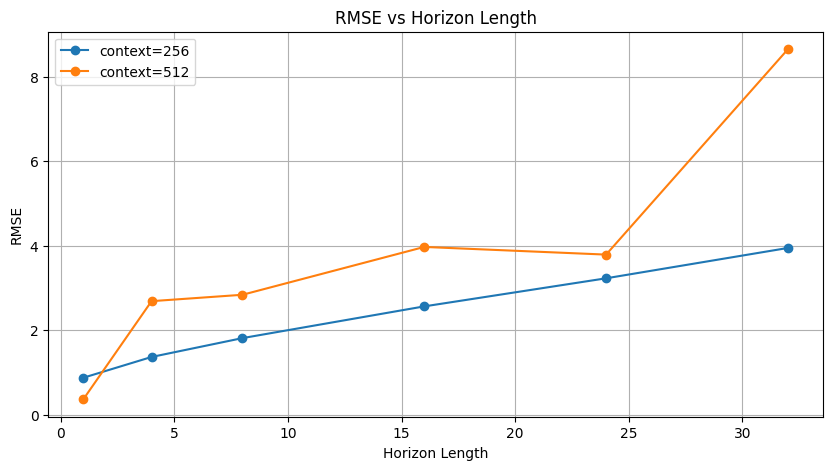

In [6]:
from collections import defaultdict

# Load results
with open("timesfm2_5_results.json", "r") as f:
    results = json.load(f)

experiments = results["experiments"]

# Organize data
rmse_by_context = defaultdict(list)
rmse_by_horizon = defaultdict(list)

for exp in experiments:
    c = exp["context_length"]
    h = exp["horizon"]
    rmse = exp["metrics"]["rmse"]

    rmse_by_context[c].append((h, rmse))
    rmse_by_horizon[h].append((c, rmse))


plt.figure(figsize=(10,5))

for c, values in rmse_by_context.items():
    values.sort()
    horizons = [v[0] for v in values]
    rmses = [v[1] for v in values]
    plt.plot(horizons, rmses, marker="o", label=f"context={c}")

plt.xlabel("Horizon Length")
plt.ylabel("RMSE")
plt.title("RMSE vs Horizon Length")
plt.legend()
plt.grid(True)
plt.show()

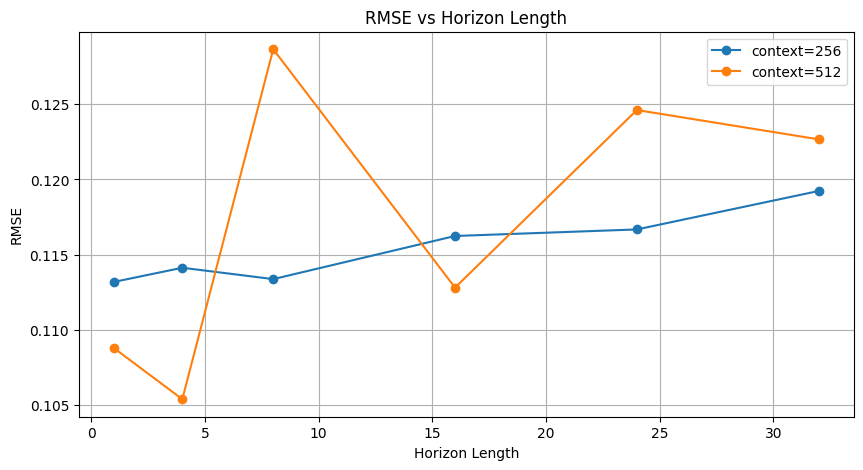

In [7]:
with open("synth_timesfm2_5_results.json", "r") as f:
    results = json.load(f)

experiments = results["experiments"]

# Organize data
rmse_by_context = defaultdict(list)
rmse_by_horizon = defaultdict(list)

for exp in experiments:
    c = exp["context_length"]
    h = exp["horizon"]
    rmse = exp["metrics"]["rmse"]

    rmse_by_context[c].append((h, rmse))
    rmse_by_horizon[h].append((c, rmse))


plt.figure(figsize=(10,5))

for c, values in rmse_by_context.items():
    values.sort()
    horizons = [v[0] for v in values]
    rmses = [v[1] for v in values]
    plt.plot(horizons, rmses, marker="o", label=f"context={c}")

plt.xlabel("Horizon Length")
plt.ylabel("RMSE")
plt.title("RMSE vs Horizon Length")
plt.legend()
plt.grid(True)
plt.show()